# Study of origins of replication

### Datasets:
- Belsky set of origins with annotations for early/late replication timing, origin efficiency, footprint evidence, and nucleosome signals.
- Estimated replication timing.
- Deconvolved chromatin occupancy data.

### Ideas:
- Show the origin timing is linked to estimated replication timing.
- Show that we can analyze footprint, and nucleosome movement timing globally.
- Show a global timecourse representation.
- Show early and late examples.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
from src.origins import load_origins
from src.replication_timing import ReplicationTiming
origins = load_origins(full=True)
replication_timings = ReplicationTiming('output/draft4_run/')

Filtering the called replication timings to 1.0 percentile (highest timing indicative of poor fit)
Filtered timings from 5482 to 5370
Number of regions removed: 112
Correlation between muller and replication timing model: 0.87


In [175]:
origin_timings = origins.copy()

from src.config import load_mean_dg1_mg1_length
g1_length = load_mean_dg1_mg1_length()
origin_timings['inferred_firing'] = False

for oridb, origin in origin_timings.iterrows():
    
    replication_time = replication_timings\
        .load_replication_entry_for(origin.chr, origin.pos).replication_time
    
    replication_time_left = replication_timings\
        .load_replication_entry_for(origin.chr, origin.pos-2000).replication_time
        
    replication_time_right = replication_timings\
        .load_replication_entry_for(origin.chr, origin.pos+2000).replication_time
    
    inferred_firing = replication_time <= replication_time_left and\
        replication_time <= replication_time_right
    
    if replication_time < replication_timings.replications_df.replication_time.max() and \
        origin.derived_origin_efficiency_from_mcguffee_et_al_2013 > 0:
        origin_timings.loc[oridb, 'replication_time'] = replication_time+g1_length
        origin_timings.loc[oridb, 'inferred_firing'] = inferred_firing

# Omit edge cases, negative efficiency and uncalled replication timing
origin_timings = origin_timings[~origin_timings.replication_time.isna()]


In [176]:
def _create_attribute(selection, false_value, true_value):
    attribute_values = np.array([false_value] * len(selection)).astype('object')
    attribute_values[selection] = true_value
    return attribute_values

alphas = _create_attribute(origin_timings.inferred_firing.values, 0.125, 1.0)

(-0.05, 0.925)

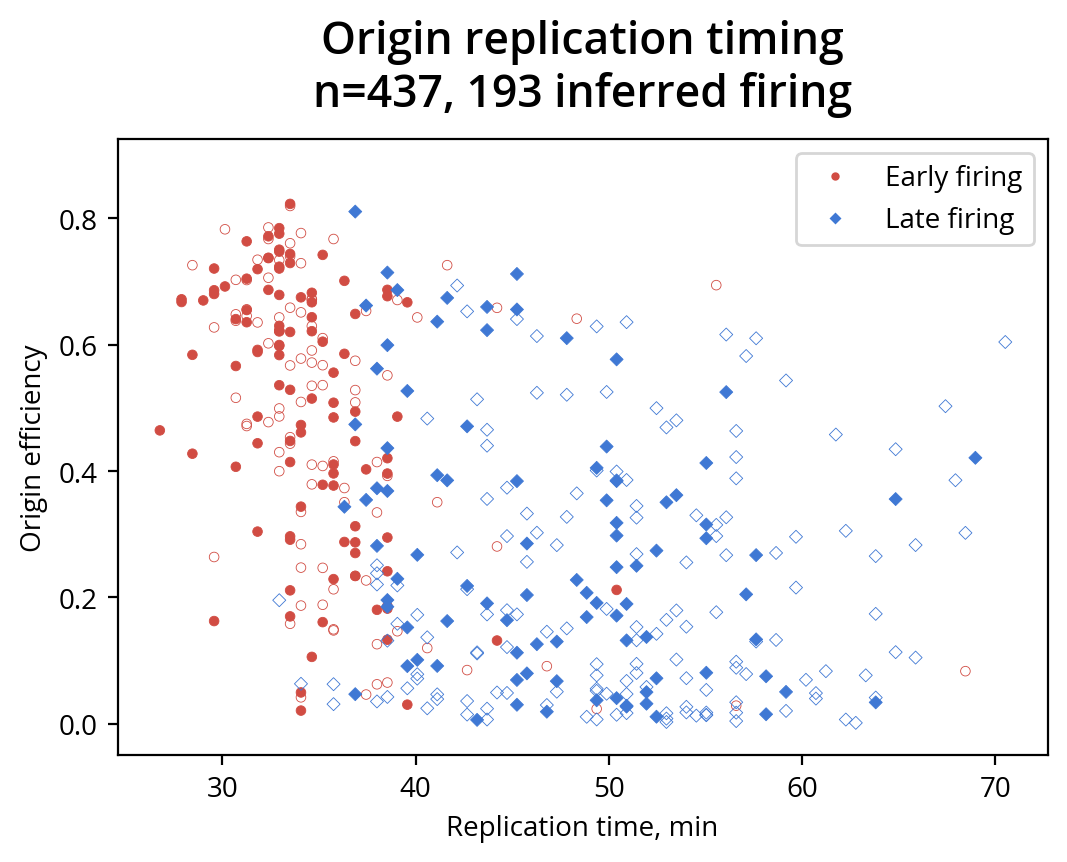

In [190]:

early_origins = origin_timings[origin_timings.activation_time == 'early']
late_origins = origin_timings[origin_timings.activation_time == 'late']

early_color = '#d14c43'
late_color = '#3f78d4'

early_facecolors = _create_attribute(early_origins.inferred_firing, 'none', 
    early_color)
late_facecolors = _create_attribute(late_origins.inferred_firing, 'none', 
    late_color)

plt.figure(figsize=(6, 4))
plt.scatter(early_origins.replication_time, 
          early_origins.derived_origin_efficiency_from_mcguffee_et_al_2013,
          s=12, edgecolor=early_color, facecolor=early_facecolors,
          label=f"Early firing, n={len(early_origins)}, {early_origins.inferred_firing.sum()}", 
            lw=0.3)

plt.scatter(late_origins.replication_time, 
          late_origins.derived_origin_efficiency_from_mcguffee_et_al_2013,
          s=11, edgecolor=late_color,
          facecolor=late_facecolors, 
            marker='D',
          label=f"Late firing, n={len(late_origins)}, {late_origins.inferred_firing.sum()}", 
            lw=0.3)

num_local_max = origin_timings.inferred_firing.sum()

plt.xlabel("Replication time, min")
plt.ylabel("Origin efficiency")
plt.title(f"Origin replication timing\nn={len(origin_timings)}, "
          f"{num_local_max} inferred firing",
         fontweight='demi', fontsize=16, pad=12)

from matplotlib.lines import Line2D

legend_elements_2 = [
    Line2D([0], [0], marker='o', color=early_color, linewidth=0,
           markersize=2, label='Early firing'),
    Line2D([0], [0], marker='D', color=late_color, linewidth=0,
           markersize=2, label='Late firing'),
]
plt.legend(handles=legend_elements_2)

plt.ylim(-0.05, 0.925)
